# Import libraries

In [2]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import emcee
import corner
import pandas as pd
%matplotlib inline
import matplotlib.lines as mlines

# Define constants

In [3]:
c = 299792.458 #is this in the correct units?
f0 = 6.61* 10**-9 * 10**(-7) * (3.2408*10**(-25))**(-2)
megaparsec = 3.0856775814913673 * 10**10

# Some key functions

In [4]:
#order of variables: z, omega_k, omega_M, omega_DE, H0, rc

def Friedmann_eq(z, omega_k, omega_M, H0):
    omega_DE = 1 - omega_k - omega_M
    H2 = (H0**2)*(omega_M*(1+z)**3 + omega_DE - omega_k*(1+z)**2)
    return np.sqrt(H2)

def integrand(z, omega_k, omega_M, H0):
    return c/Friedmann_eq(z, omega_k, omega_M, H0)

def co_moving_dist(z_up, omega_k, omega_M, H0):
    z_up = np.concatenate(([0], z_up))
    r_cm = scp.integrate.odeint(lambda y, t: integrand(t, omega_k, omega_M, H0), 0, z_up)
    r_c = np.delete(r_cm, 0)
    return np.ndarray.flatten(r_c) #comoving distance in Mpc?

def Sk(omega_k, H0, rc): #units issue?
    if omega_k == 0:
        return rc
    if omega_k < 0:
        return (c/(H0*np.sqrt(-omega_k)))*np.sin(np.sqrt(-omega_k)*rc*H0/c)
    return (c/(H0*np.sqrt(omega_k)))*np.sinh(np.sqrt(omega_k)*rc*H0/c)

def dist_modulus(z, omega_k, omega_M, H0):
    rc = co_moving_dist(z, omega_k, omega_M, H0)
    s_k = Sk(omega_k, H0, rc)
    dl = (1+z)*s_k
    dist_mod = 5*np.log10(dl) + 25
    return dist_mod

In [5]:
#different equations of state:

"""w = w0 #wCDM
w = w0 + wa*(1+z)"""


'w = w0 #wCDM\nw = w0 + wa*(1+z)'

# Load the data

In [6]:
sn_z, sn_z_err, sn_mu, sn_mu_err = np.loadtxt("pantheon-plus+SH0ES-SN.txt", usecols=(2,3,4,5), unpack = True)
covmat_file = np.loadtxt("Pantheon+SH0ES_STAT+SYS.cov")
covmat_file_dim = int(covmat_file[0])
covmat_file = np.delete(covmat_file, 0)
covmat = np.zeros((covmat_file_dim, covmat_file_dim))
covmat.shape
for i in range(covmat_file_dim):
    covmat[i] = covmat_file[i*covmat_file_dim:(i+1)*covmat_file_dim]
covmat_inv = np.linalg.inv(covmat)


In [7]:
"""plt.figure(1)
plt.scatter(sn_z, sn_mu, marker = "x")
z_test = np.linspace(0, 2.5, 1000)
mu_test = dist_modulus(z_test, 0, 0.334, 0.666, 73.6)
plt.plot(z_test, mu_test, color = "r")
plt.xscale("log")

plt.show()
resids = (dist_modulus(sn_z, 0, 0.334, 0.666, 73.6) - sn_mu)/sn_mu_err
plt.figure(2)
plt.scatter(sn_z, resids, marker = "x")
plt.xscale("log")
plt.show()"""

'plt.figure(1)\nplt.scatter(sn_z, sn_mu, marker = "x")\nz_test = np.linspace(0, 2.5, 1000)\nmu_test = dist_modulus(z_test, 0, 0.334, 0.666, 73.6)\nplt.plot(z_test, mu_test, color = "r")\nplt.xscale("log")\n\nplt.show()\nresids = (dist_modulus(sn_z, 0, 0.334, 0.666, 73.6) - sn_mu)/sn_mu_err\nplt.figure(2)\nplt.scatter(sn_z, resids, marker = "x")\nplt.xscale("log")\nplt.show()'

In [8]:
"""initial = [0, 0.3, 0.7, 70]
popt, cov = scp.optimize.curve_fit(dist_mod_2, sn_z, sn_mu, sigma = sn_mu_err, absolute_sigma=True, p0=initial, check_finite=True)
print(popt)
def log_likelihood2(theta, z, mu, muerr):
    omega_k, omega_M, omega_DE, H0 = theta
    model = dist_modulus(z, omega_k, omega_M, omega_DE, H0)
    resids = mu - model
    chi2 = np.sum(resids**2/muerr**2)
    return -0.5*chi2

nll = lambda *args: -log_likelihood2(*args)"""
#soln = scp.optimize.minimize(nll, initial, args=(sn_z, sn_mu, sn_mu_err))
#print(soln.x)


'initial = [0, 0.3, 0.7, 70]\npopt, cov = scp.optimize.curve_fit(dist_mod_2, sn_z, sn_mu, sigma = sn_mu_err, absolute_sigma=True, p0=initial, check_finite=True)\nprint(popt)\ndef log_likelihood2(theta, z, mu, muerr):\n    omega_k, omega_M, omega_DE, H0 = theta\n    model = dist_modulus(z, omega_k, omega_M, omega_DE, H0)\n    resids = mu - model\n    chi2 = np.sum(resids**2/muerr**2)\n    return -0.5*chi2\n\nnll = lambda *args: -log_likelihood2(*args)'

## Priors

Parameters of model are: {k, H0, omega_M, omega_DE}

Priors are: {k=0, H0~70, etc}

Should priors be uniform or Gaussian over the range? - use uniform unless I have good reasons to use a Gaussian (eg if I use the Planck result as a prior, the prior could be a Gaussian with st dev being the error given by Planck)

In [9]:
H0_prior = 69.02
H0_stdev_prior = 2.08*5
omega_DE_prior = 0.6889
omega_DE_stdev_prior = 0.0056
omega_M_prior = 0.31
omega_M_stdev_prior = 0.04

def log_prior(theta, z):
    omega_k, omega_M, H0 = theta
    omega_DE = 1 - omega_k - omega_M
    H2 = (H0**2)*(omega_M*(1+z)**3 + omega_DE - omega_k*(1+z)**2)
    if not (-0.5<omega_k<0.5 and np.all(H2>0) and H0>0):
        return -np.inf
    return -0.5*(omega_M-omega_M_prior)**2/omega_M_stdev_prior**2 -0.5*(H0-H0_prior)**2/H0_stdev_prior**2


nparams = 3
nwalkers = 50
pos = np.zeros((nwalkers, nparams))
for i in range(len(pos)):
    pos[i][0] = np.random.uniform(-0.005, 0.005)
    pos[i][1] = np.random.uniform(0.2, 0.4)
    pos[i][2] = np.random.uniform(60, 80)

# Likelihood function

In [10]:
def log_likelihood(theta, z, mu, covmatrix_inv):
    omega_k, omega_DE, H0 = theta
    model = dist_modulus(z, omega_k, omega_DE, H0)
    resids = mu - model
    chi2 = np.matmul(np.matmul(resids, covmatrix_inv), resids)
    return -0.5*chi2
    


def log_probability(theta, z, mu, covmatrix_inv):
    lp = log_prior(theta, z)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu, covmatrix_inv)


# The MCMC algorithm

Questions to investigate: how many chains should I discard? What is burn in? How many walkers do I need? How many steps should the walkers take?

In [11]:
nsteps = 40000 #number of steps walkers take
nwalkers, ndim = pos.shape
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args = (sn_z, sn_mu, covmat_inv)
)
sampler.run_mcmc(pos, nsteps, progress = True)

100%|██████████| 40000/40000 [2:02:13<00:00,  5.45it/s]  


State([[-1.57355686e-01  3.34054438e-01  6.37786036e+01]
 [ 7.07378685e-03  3.54905383e-01  7.31504375e+01]
 [-1.27250786e-01  3.89259777e-01  6.47597009e+01]
 [ 1.35453757e-03  3.75172944e-01  7.29405150e+01]
 [-5.54180146e-02  3.46018707e-01  6.93448519e+01]
 [ 1.06837311e-03  3.73541636e-01  7.27951411e+01]
 [-2.27566010e-01  3.56878991e-01  6.04470450e+01]
 [ 1.15131459e-01  3.52964511e-01  8.29903641e+01]
 [-2.53169773e-01  3.50197493e-01  5.94511568e+01]
 [-1.33721980e-01  3.01021285e-01  6.52041705e+01]
 [-4.77742067e-01  3.85172087e-01  5.20909572e+01]
 [ 5.84592104e-02  3.66596883e-01  7.75277847e+01]
 [-7.09104834e-03  3.49935391e-01  7.25050507e+01]
 [ 1.24651962e-01  3.69191668e-01  8.39166168e+01]
 [ 4.43748671e-02  3.49169368e-01  7.63611110e+01]
 [-3.44089218e-01  3.30894665e-01  5.61855350e+01]
 [ 6.38932041e-02  3.50307183e-01  7.80390016e+01]
 [ 2.07048773e-02  3.56668911e-01  7.45286182e+01]
 [ 2.53037532e-02  3.50356770e-01  7.47129597e+01]
 [ 1.42510671e-01  3.4050

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 1140;
tau: [1250.97799552  145.18721336 1295.61325063]

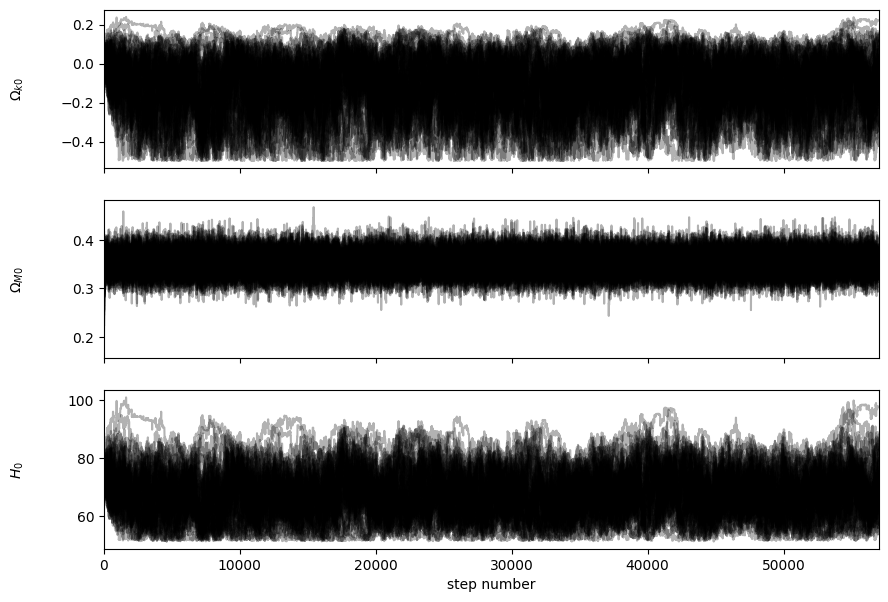

In [19]:
#sampler.run_mcmc(None, 17000, progress = True)
ndiscard = 200 #how many steps at the beginning of the chain to discard
flat_samples = sampler.get_chain(discard = ndiscard, thin = 15, flat = True)

fig, axes = plt.subplots(nparams, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["$Ω_{k0}$", "$Ω_{M0}$", "$H_{0}$"] 
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");
plt.savefig("walkers_LCDM.png")
print(f"autocorrelation time is {sampler.get_autocorr_time()}")

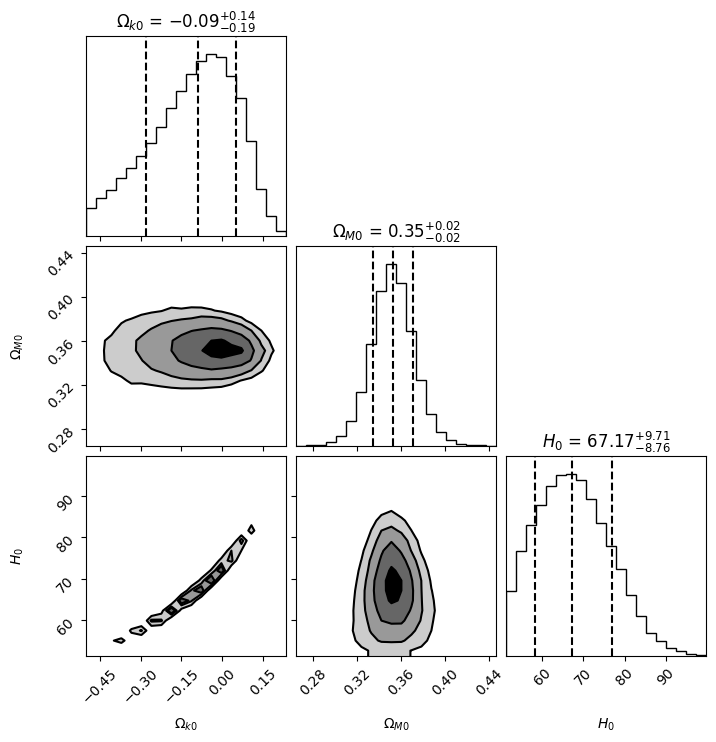

In [17]:
fig = corner.corner(
    flat_samples, labels = labels, quantiles=[0.16,0.5,0.84], show_titles=True, title_kwargs={"fontsize": 12}, plot_datapoints=False, fill_contours = True
)
plt.savefig("corner_LCDM.png")

# Covariance plots

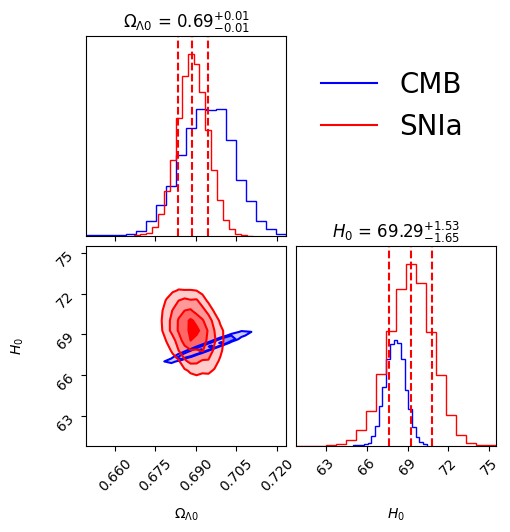

In [44]:
# MCMC chain samples - using 2018 TT,TE,EE+lowE+lensing+BAO result
planck_samples = np.loadtxt("planck_chains_2018.txt")

# load the column names for the samples
column_names_raw = np.loadtxt("planck_param_names_2018.paramnames", dtype=str, usecols=[0])
column_names = [x.replace("b'",'').replace("'",'') for x in column_names_raw]

# make a data frame with column names and samples
samples1 = pd.DataFrame(planck_samples[:,2:], columns=column_names) # first two columns are not important
mysamples = flat_samples
sigma1 = 1. - np.exp(-(1./1.)**2/2.)
sigma2 = 1. - np.exp(-(2./1.)**2/2.)
use_params = ["omegal*", "H0*"]
fig = corner.corner(samples1[use_params], color = "b", plot_datapoints=False, fill_contours=True)

corner.corner(
    flat_samples[:,[1,2]], labels = labels[1:], quantiles=[0.16,0.5,0.84], show_titles=True, title_kwargs={"fontsize": 12}, color = "r",
    plot_datapoints=False, fill_contours=True, fig=fig
)
colors = ["b", "r"]
sample_labels = ["CMB", "SNIa"]
plt.legend(
        handles=[
            mlines.Line2D([], [], color=colors[i], label=sample_labels[i])
            for i in range(2)
        ],
        fontsize=20, frameon=False,
        bbox_to_anchor=(0, 2),
        loc="upper left"
    )
plt.savefig("corner_LCDM_Planck.png")
plt.show()

In [1]:

with open("flat_samples_LCDM.txt", "a") as f:
    samples = sampler.get_chain(flat = True)
    for walkercoords in samples:
        f.write(str(walkercoords))
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]} + {q[1]} - {q[0]}")
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]} + {q[1]} - {q[0]}")

NameError: name 'sampler' is not defined

In [37]:
omega_k_model = np.percentile(flat_samples[:, 0], [50])
omega_DE_model = np.percentile(flat_samples[:, 1], [50])
H0_model = np.percentile(flat_samples[:, 2], [50])

1752.6411689084362


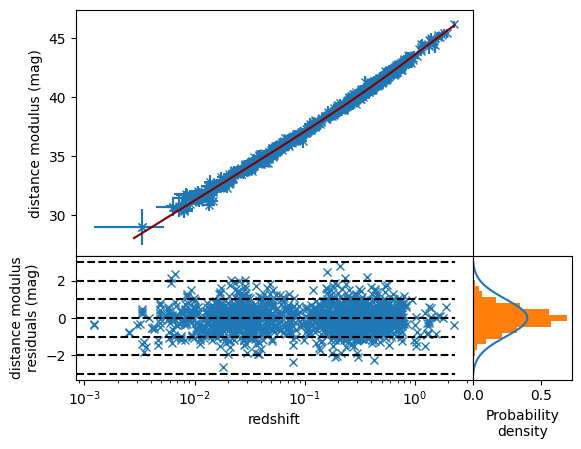

BIC: 1774.9580836856237


In [38]:
model_z = np.linspace(0.001, 2.3, 1000)
model_mu = dist_modulus(model_z, omega_k_model, omega_DE_model, H0_model)
#bad_mu = dist_modulus(model_z, 0, 0.334, 0.666, 73.6)
resids = sn_mu - dist_modulus(sn_z, omega_k_model, omega_DE_model, H0_model)
chisqval = np.matmul(np.matmul(resids, covmat_inv), resids) # need to double check this


fig, axs = plt.subplots(2, 2, width_ratios=[4,1], height_ratios=[2,1])
axs[0,0].plot(model_z, model_mu, color = "maroon", zorder = 2)
#axs[0,0].plot(model_z, bad_mu, color = "g", zorder = 3)

axs[0,0].errorbar(sn_z, sn_mu, xerr=sn_z_err, yerr = sn_mu_err, marker = "x", linestyle = 'None', zorder = 1)
#axs[0,0].fill_between(trial_z, trial_mag_lower, trial_mag_upper, color = "purple", alpha = 0.75, label = "high z model")
#axs[0].errorbar(sn_z_far, sn_mag_far, yerr=sn_mag_err_far, marker = "x", linestyle = 'None', color = "blue", label = "distant SN")
axs[1,0].hlines(1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(2,0,2.3, linestyle = "--", color = "black")
norm_resids = (dist_modulus(sn_z, omega_k_model, omega_DE_model, H0_model) - sn_mu)/sn_mu_err
print(chisqval)
axs[1,0].errorbar(sn_z, norm_resids, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-2,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(0,0,2.3, linestyle = "--", color = "black", zorder = 2)
axs[1,0].set_xlabel("redshift")
axs[0,0].set_ylabel("distance modulus (mag)")
axs[1,0].set_ylabel("distance modulus\nresiduals (mag)")
fig.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0)
#axs[0,0].invert_yaxis()
axs[0,0].set_xscale("log")
axs[1,0].set_xscale("log")
axs[0,1].remove()
axs[1,1].get_yaxis().set_visible(False)
xs = np.linspace(-3,3)
axs[1,1].plot(scp.stats.norm.pdf(xs, 0, 1), xs)
axs[1,1].set_xlabel("Probability\ndensity")
axs[1,1].hist(norm_resids, density = True, orientation = u'horizontal', bins = np.linspace(-3, 3, 20))
plt.savefig("plot_LCDM", bbox_inches = "tight")
plt.show()
BIC = nparams*np.log(covmat_file_dim) + chisqval
print(f"BIC: {BIC}")